# Convolutional Neural Networks (CNN)

Phân loại ảnh biểu tượng giao thông 28×28 (6 lớp) bằng CNN trên Keras.

**Quy trình**
1. Load dữ liệu
2. Chuẩn hóa, reshape, one-hot encoding
3. Tách train / validation
4. Xây dựng mô hình CNN
5. Compile, tăng cường dữ liệu và huấn luyện
6. Đánh giá

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPool2D
from keras.models import Sequential
from keras.optimizers import Adam
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")

DATA_DIR = Path("datasets/transportation_cnn")
if not DATA_DIR.exists():
    DATA_DIR = Path("../datasets/transportation_cnn")
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Không tìm thấy {DATA_DIR.resolve()}. Chạy notebook từ week2 hoặc PRN501-CNN-report."
    )

print("Dataset files:", sorted(os.listdir(DATA_DIR)))

Dataset files: ['class_labels.csv', 'images', 'transportation_test.csv', 'transportation_test_paths.csv', 'transportation_train.csv', 'transportation_train_paths.csv']


## 1. Load dữ liệu

Mỗi dòng là một ảnh xám 28×28 (784 pixel) kèm nhãn `label` (0–5).

In [2]:
train = pd.read_csv(DATA_DIR / "transportation_train.csv")
test = pd.read_csv(DATA_DIR / "transportation_test.csv")

Y_train = train["label"]
X_train = train.drop(columns=["label"])
Y_test = test["label"]
X_test = test.drop(columns=["label"])

print("train:", train.shape, "| test:", test.shape)
print(Y_train.value_counts().sort_index())
train.head()

train: (480, 785) | test: (120, 785)
label
0    80
1    80
2    80
3    80
4    80
5    80
Name: count, dtype: int64


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,245,247,255,255,255,241,240,255,242,...,234,230,244,245,238,255,239,255,255,255
1,0,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
2,0,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
3,0,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
4,0,255,255,255,242,255,246,236,240,255,...,252,253,255,231,251,236,255,234,236,254


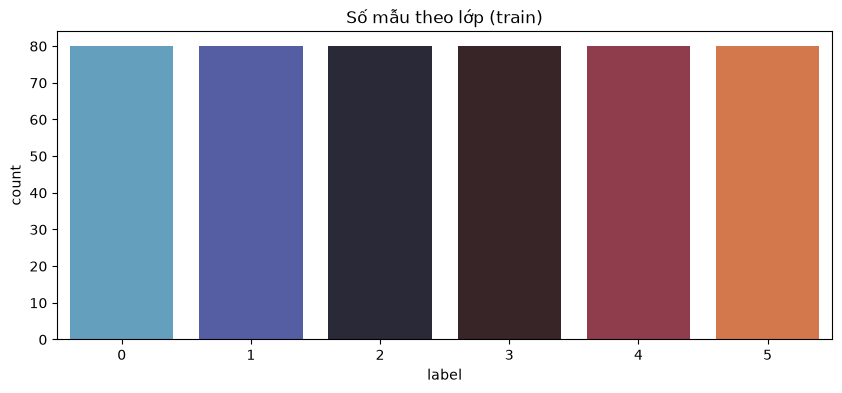

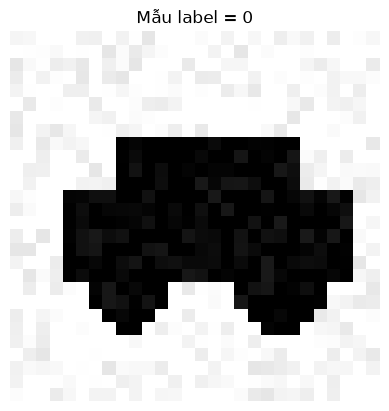

In [3]:
plt.figure(figsize=(10, 4))
sns.countplot(x=Y_train, palette="icefire")
plt.title("Số mẫu theo lớp (train)")
plt.show()

img = X_train.iloc[0].to_numpy().reshape(28, 28)
plt.imshow(img, cmap="gray")
plt.title(f"Mẫu label = {Y_train.iloc[0]}")
plt.axis("off")
plt.show()

## 2. Chuẩn hóa, reshape, one-hot encoding

- Chia pixel cho 255 để CNN hội tụ nhanh hơn.
- Đưa ảnh về `(28, 28, 1)` — Keras cần chiều kênh (ảnh xám = 1 kênh).
- One-hot nhãn: ví dụ `2 → [0, 0, 1, 0, 0, 0]`.

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.values.reshape(-1, 28, 28, 1)
X_test = X_test.values.reshape(-1, 28, 28, 1)

Y_train = to_categorical(Y_train, num_classes=6)
Y_test = to_categorical(Y_test, num_classes=6)

print("X_train:", X_train.shape, "| Y_train:", Y_train.shape)
print("X_test :", X_test.shape, "| Y_test :", Y_test.shape)

X_train: (480, 28, 28, 1) | Y_train: (480, 6)
X_test : (120, 28, 28, 1) | Y_test : (120, 6)


## 3. Tách train / validation

Giữ 10% tập train làm validation khi huấn luyện.

In [5]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train, Y_train, test_size=0.1, random_state=2
)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("Y_train:", Y_train.shape, "| Y_val:", Y_val.shape)

X_train: (432, 28, 28, 1) | X_val: (48, 28, 28, 1)
Y_train: (432, 6) | Y_val: (48, 6)


## 4. Xây dựng mô hình CNN

Luồng CNN: **Conv2D → MaxPool → Dropout → Conv2D → MaxPool → Dropout → Flatten → Dense → Softmax**.

- **Conv2D**: lọc đặc trưng (cạnh, hình khối).
- **Same padding**: giữ kích thước feature map.
- **MaxPool**: giảm kích thước, giảm overfitting.
- **Flatten + Dense**: đưa đặc trưng vào lớp fully connected để phân loại 6 lớp.

In [6]:
model = Sequential([
    Conv2D(filters=8, kernel_size=(5, 5), padding="Same", activation="relu", input_shape=(28, 28, 1)),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.25),
    Conv2D(filters=16, kernel_size=(3, 3), padding="Same", activation="relu"),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(6, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 8)           │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 203,878 (796.40 KB)

 Trainable params: 203,878 (796.40 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile, data augmentation và huấn luyện

- Optimizer **Adam**, loss **categorical_crossentropy** (đa lớp).
- Data augmentation xoay / zoom / dịch nhẹ để giảm overfitting.

In [7]:
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

epochs = 10
batch_size = 250

datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False,
)
datagen.fit(X_train)

history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(X_val, Y_val),
    steps_per_epoch=X_train.shape[0] // batch_size,
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2033 - loss: 1.8409 - val_accuracy: 0.1042 - val_loss: 1.7819
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1400 - loss: 1.9345 - val_accuracy: 0.2917 - val_loss: 1.7519
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1209 - loss: 1.9318 - val_accuracy: 0.1875 - val_loss: 1.7252
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1520 - loss: 1.8797 - val_accuracy: 0.3542 - val_loss: 1.7255
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2480 - loss: 1.7508 - val_accuracy: 0.3333 - val_loss: 1.7182
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2473 - loss: 1.7560 - val_accuracy: 0.3125 - val_loss: 1.7157
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.2400 - loss: 1.7690 - val_accuracy: 0.2708 - val_loss: 1.7038
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2637 - loss: 1.7155 - val_accuracy: 0.3333 - val_loss: 1.6909
E

## 6. Đánh giá

Theo dõi loss trên validation và ma trận nhầm lẫn.

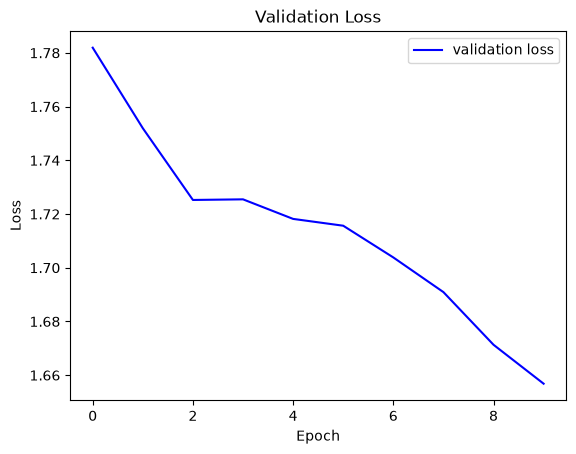

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


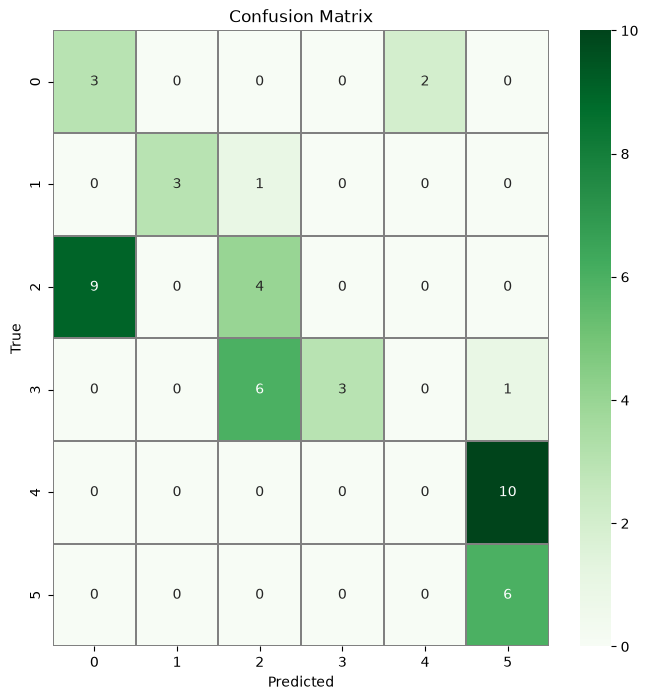

In [8]:
# ==============================================================================
# 4: DỰ ĐOÁN VÀ ĐÁNH GIÁ MÔ HÌNH (PREDICTION & EVALUATION) - huy26ms23394@fsb.edu.vn
# ==============================================================================

# 1. Trực quan hóa Validation Loss qua từng Epoch
# Giúp theo dõi quá trình học của mô hình và phát hiện dấu hiệu Overfitting (nếu val_loss bắt đầu tăng lại)
plt.plot(history.history["val_loss"], color="b", label="validation loss")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 2. Thực hiện dự đoán trên tập dữ liệu Validation (X_val)
# Mô hình trả về một mảng chứa 6 giá trị xác suất (Probability) tương ứng với 6 lớp cho mỗi ảnh
Y_pred = model.predict(X_val)

# 3. Sử dụng hàm argmax để lấy chỉ số (index) của lớp có xác suất dự đoán lớn nhất
Y_pred_classes = np.argmax(Y_pred, axis=1)

# 4. Chuyển nhãn thực tế từ dạng One-hot Encoding về lại dạng chỉ số lớp (Integer Class)
Y_true = np.argmax(Y_val, axis=1)

# 5. Tạo ma trận nhầm lẫn (Confusion Matrix) để so sánh các cặp lớp thực tế (Y_true) và lớp dự đoán (Y_pred_classes)
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

# 6. Trực quan hóa ma trận nhầm lẫn dưới dạng biểu đồ nhiệt (Heatmap)
plt.figure(figsize=(8, 8))
sns.heatmap(
    confusion_mtx,
    annot=True,         # Hiển thị số lượng mẫu chi tiết ngay trên từng ô của ma trận
    fmt="d",            # Định dạng kiểu hiển thị số nguyên
    cmap="Greens",      # Tông màu hiển thị xanh lá
    linewidths=0.01,    # Độ rộng đường ranh giới giữa các ô
    linecolor="gray",   # Màu đường ranh giới giữa các ô
)
plt.xlabel("Predicted") # Trục hoành (X-axis) biểu thị lớp mô hình dự đoán
plt.ylabel("True")      # Trục tung (Y-axis) biểu thị lớp thực tế (Ground Truth)
plt.title("Confusion Matrix")
plt.show()